Topic modeling has become a popular method for uncovering latent themes in
large text corpora, but its outputs are not self-evidently correct. Because
most topic models are inductive and unsupervised, there is no predefined
answer to check them against — and even the object a topic model is
supposed to recover, "a topic," is not something the field agrees on a
single definition for. Classical models like LDA define a topic as a
probability distribution over words; embedding-based methods such as
Top2Vec [@angelov2020top2vec], which BERTopic builds on, instead define a
topic as a semantic cluster of documents and words positioned by meaning in
a shared vector space — a genuinely different construct, not just a
different way of measuring the same thing. Because what counts as "a
topic" already depends on the method and the question being asked, a single 
gold standard does not allow us judge any topic model's output as simply 
right or wrong beyond the context of one specific research question 
[@bernhardharrer2026beyond].

This is not a gap that better tools will eventually close. Classical
statistical methods, like a regression, assume a single "true"
data-generating process that the model tries to approximate, so validation
can ask how closely the model matches that assumed reality. Topic
modeling, as an inductive and largely unsupervised method, makes no such
assumption — there simply is no one "correct" number of topics or
"correct" partition of a corpus waiting to be discovered. A topic model's
usefulness instead depends on the purpose it serves: one model might suit
summarizing documents, another tracking a theme over time, even on the
same corpus. This is why insisting on one standardized validation metric,
applied the same way regardless of purpose, does not fit topic modeling
[@bernhardharrer2026beyond]. One of the earliest practical responses to this 
problem is the roadmap Maier and colleagues [-@maier2018applying] developed 
for applying and evaluating LDA topic models in communication research — a 
roadmap whose logic (screen candidate models cheaply, then validate the chosen 
one more thoroughly) this tutorial's own strategy draws on throughout.

This tutorial walks through how to validate a topic model built with
BERTopic [@grootendorst2022bertopic], giving you a practical, hands-on
sense of several validation approaches so you can choose and justify the
ones that fit your own research question.

## Learning Objectives

By the end of this tutorial, you will be able to

1. Explain why topic model validation cannot rely on a single standardized metric, and why the choice of validation method should follow from the model's intended use.
2. Distinguish between model *selection* (narrowing down and choosing among candidate models) and model *validation* (justifying that the chosen model is fit for purpose), and explain why using the same method for both risks circular reasoning.
3. Fit a BERTopic model on a text corpus, screen a set of candidate models with automated metrics, and narrow them down to a shortlist using qualitative, human-judgment-based inspection.
4. Justify a selected topic model as valid — theoretically and methodologically — and decide, with an eye on potential bias, whether any of its topics should be merged or disregarded before it is used for further analysis.
5. Create a validation strategy for your own topic modeling project, selecting and justifying the combination of validation approaches best suited to your research question, and report that strategy transparently.

## Target audience

This tutorial is aimed at researchers and students in the social sciences with some prior experience using Python and a basic familiarity with topic modeling. No prior experience with validation methods is assumed.

## Setting up the computational environment

e.g. The following Python packages are required:

In [1]:
pip install numpy


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Duration

maybe half a work day, including the qualitative validation.

## Social Science Usecase(s)

Topic modeling has been widely applied across the social sciences — for
example in political communication, journalism studies, and migration
research — to identify latent themes in large text corpora (e.g.,
on media framing of the European refugee crisis [@heidenreich2019media]).
Because such applications are often used to build or test social scientific
theory, the validity of the resulting topics matters directly for the
credibility of the substantive findings. Yet a systematic review of
validation practices across 789 studies found no convergence toward
standardized validation methods, showing that researchers must actively
choose and justify a validation strategy suited to their research question
[@bernhardharrer2026beyond]. This is not merely a theoretical concern:
applying different validation methods to the same text corpus has been
shown to lead researchers toward different model choices and,
consequently, different substantive conclusions [@bernhard2023topic].
This tutorial demonstrates how to build and validate a topic model using
BERTopic [@grootendorst2022bertopic], a transformer-based topic modeling
approach.

## The Data

This tutorial uses the HuffPost News Category Dataset [@misra2022news], a
large collection of English-language news headlines and short descriptions
published by HuffPost between 2012 and 2018. We load it directly via the
Hugging Face `datasets` library (`khalidalt/HuffPost`).

In [2]:
# We use pandas to read the dataset directly from Hugging Face. The data
# is stored there in Parquet format, an efficient file format for storing
# large tables, which pandas can read straight from a URL.
import pandas as pd

df = pd.read_parquet(
    "https://huggingface.co/datasets/khalidalt/HuffPost/"
    "resolve/refs%2Fconvert%2Fparquet/default/test/0000.parquet"
)

# Quick check: print the shape (rows, columns) to see how many
# articles we downloaded, and preview the first few rows to see what
# columns are available.
print(df.shape)
df.head()

(200853, 7)


,category,headline,authors,link,short_description,date,label
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26,20
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26,2
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26,2
3,ENTERTAINMENT,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,Ron Dicker,https://www.huffingtonpost.com/entry/jim-carre...,The actor gives Dems an ass-kicking for not fi...,2018-05-26,2
4,ENTERTAINMENT,Julianna Margulies Uses Donald Trump Poop Bags...,Ron Dicker,https://www.huffingtonpost.com/entry/julianna-...,"The ""Dietland"" actress said using the bags is ...",2018-05-26,2


In this dataset we have the following columns available.

- `headline` — the article headline
- `short_description` — a one- to two-sentence summary of the article
- `category` — the HuffPost section the article was published under (41
  categories, e.g. `"POLITICS"`, `"SPORTS"`)
- `label` - a numerical representation of `category`
- `date` — the publication date (`YYYY-MM-DD`) — our time variable, which
  we'll use to look at how topics develop over time
- `authors` — the article's byline(s)
- `link` — URL to the original article (not used in this tutorial)

In [3]:
# BERTopic expects one string of text per document. Since each row here
# has two short text fields, we combine the headline and short description
# into a single `text` column that we'll feed into the model later.
df["text"] = df["headline"] + ". " + df["short_description"]

# The full corpus has close to 200,000 articles. Sweeping across multiple
# candidate BERTopic models on all of them would be slow, so we draw a random 
# subset of 5,000 articles instead. Setting random_state makes the sample reproducible: 
# rerunning this cell will always select the same 5,000 articles.
df = df.sample(n=5000, random_state=42).reset_index(drop=True)

# Quick check: print the shape (rows, columns) to see if the sampling worked.
print(df.shape)

(5000, 8)


## Preprocessing: Cleaning the Data

This dataset comes already deduplicated and free of empty entries, so we
don't need an explicit cleaning step here. When working with your own
data, however, this step is worth taking seriously — especially if your
text comes from web scraping, combines multiple sources, or was exported
from a database. Before fitting a topic model, it's good practice to
check for:

- **Exact duplicates** — the same text appearing more than once (e.g.,
  a press release or article re-published under different IDs)
- **Empty or near-empty texts** — rows where a failed scrape, missing
  field, or export error left little or no usable text
- **Extreme outliers in text length** — documents that are unusually
  short or long compared to the rest of the corpus can distort embeddings
  and topic assignments
- **Leftover artifacts** — HTML tags, boilerplate (e.g., "Subscribe to
  our newsletter"), or encoding errors that slipped through during
  collection
- **Missing values in metadata columns** you plan to use later (e.g., a
  missing date would break the time-based analysis in this tutorial)

A quick way to check the first two is:

```python
print(df.duplicated(subset="text").sum(), "duplicate texts")
print((df["text"].str.strip().str.len() == 0).sum(), "empty texts")
```

If either count is above zero, drop those rows before moving on.

It's also worth noting that how much preprocessing your text needs
depends heavily on which topic modeling algorithm you use. BERTopic, the
method used in this tutorial, is an embedding-based approach: it relies
on a pretrained language model to represent documents as dense vectors
based on their meaning, rather than on raw word-frequency statistics.
Because of this, BERTopic generally needs much less aggressive text
preprocessing than classical algorithms like LDA, which rely on word
co-occurrence counts and are typically applied to text that has been
lowercased, stemmed or lemmatized, and stripped of stopwords, numbers,
and punctuation. These preprocessing choices are not neutral and should
be made with theoretical justification, as they substantially affect
the results of text analysis [-@denny2018text].

## What Do We Mean by "Validation"?

Before planning a validation strategy, it's worth being precise about what
"validation" and "validity" actually mean here, since the word gets used
loosely. In the social sciences, validity broadly asks whether a measure
captures what it claims to capture — whether a model's output can be
trusted as a fair representation of the thing you set out to study.
Drawing on the wider content-analysis literature, Bernhard-Harrer et al.
[-@bernhardharrer2026beyond] distinguish, following Krippendorff
[-@krippendorff2013content], *face validity* (is a result plausible on its
face), *social validity* (does it address something of genuine social
relevance), and *empirical validity* (does available evidence and
established theory actually support it) — the last of these further split
into content, structural, and relational sub-dimensions. DiMaggio and
colleagues [-@dimaggio2013exploiting], cited in the same review, offer a
classification suited more specifically to inductive text methods:
*statistical validity* (does the model fit its own statistical
assumptions), *semantic* or *internal validity* (does the model
meaningfully distinguish between different word senses), and *external* or
*predictive validity* (does a topic respond the way we'd expect given
known events).

Bernhard-Harrer and colleagues used this taxonomy to sort the validation
practices of 789 published studies into eight overarching categories:
Model Comparison, Internal Qualitative Inspection, External Qualitative
Inspection, Error Rate Analysis, Distinctiveness of Top Words, Information
Theory Metrics, Similarity and Distance Metrics, and Downstream Tasks.
None of these is inherently "better" than the others — each captures a
different kind of evidence, with its own blind spots (Error Rate Analysis
needs a trustworthy gold standard to compare against; Internal Qualitative
Inspection needs a reader who genuinely understands qualitative methods,
and so on). Their central empirical finding was that, across two decades
of research, the field has not converged on any particular combination of
these categories. As laid out in the introduction, their argument is that
it should not be expected to: because a topic model's usefulness is
contingent on its purpose, validity for a topic model is not a single,
fixed target, but a question of whether the model does what you needed it
to do — argued for using whichever combination of these eight lenses best
fits that purpose, and reported transparently so a reader can judge the
argument for themselves.

Please note that this tutorial only shows *one* possible way of validating a 
topic model, this is not a template to be reused unchanged for any different 
research question.

## Planning a Validation Strategy

Before running any models, it is essential to plan the validation design. 
As the introduction laid out, there is no single standardized way
to validate a topic model — the right approach depends on what the model
needs to do. Bernhard et al. [-@bernhard2023topic] propose a practical
starting point: before applying a topic model, describe what a *good*
model would actually look like, then use that description to decide which
validation methods are worth applying.

Concretely, this means asking a few questions up front:

1. **What would a good model look like?** In a real research project,
   this description should be grounded in theoretical knowledge of your
   substantive domain — what themes does your research question, prior
   literature, or subject-matter expertise lead you to expect? For this
   tutorial, we don't have a specific research question to draw on, but we
   do know something about the source: HuffPost is a general-interest
   news outlet, so regardless of the exact model we end up with, we would
   expect at least some broad, recognizable topics to emerge — things
   like politics, entertainment, sport, and business/economy, mirroring
   the kind of sections a general news outlet typically covers. A good
   model, then, would be one whose topics are individually interpretable,
   and include these expected themes.
2. **What would tell us whether a model meets that description?** Since
   we don't have manually annotated "ground truth" topics for this
   corpus, we can't rely on error-rate metrics like precision or recall.
   Instead, we combine automated statistical measures (to narrow down a
   large set of candidate models cheaply) with human judgment (to check
   whether the surviving candidates are actually interpretable) and a
   comparison against the existing `category` metadata (as an external,
   if imperfect, reference point).
3. **Which specific methods fit those angles?** Bernhard-Harrer et al.
   [-@bernhardharrer2026beyond] group topic model validation approaches
   into eight broad categories — among them Model Comparison, Internal
   Qualitative Inspection, External Qualitative Inspection, and
   Information Theory Metrics — each reflecting a different kind of
   evidence about a model's validity. Reading through that framework 
   before picking methods helps ensure the choices aren't arbitrary, 
   and helps you build a comparable strategy for your own research.
4. **How will model selection and model validation be kept separate?**
   Using the same method to both pick a model and then declare it valid
   is circular. Everything that narrows the candidate models down to a
   single final model — automated screening, but also the
   labor-intensive, human-judgment-based checks below — counts as
   *selection*. *Validation* is a separate step that only begins once one
   model has actually been chosen: it doesn't compare that model against
   alternatives again, but builds the case for why it should be trusted.

Following this logic, this tutorial applies:

- **Screening (Model Comparison / Information Theory Metrics):** NPMI and
  C_v coherence, topic diversity, and a fully automated category-purity
  score (how concentrated each topic is in a single existing `category`
  label), to cheaply narrow the candidate models down to a shortlist.
- **Internal Qualitative Inspection:** a word intrusion task, to check
  whether topics are semantically coherent, and manual topic labeling, to
  check whether topics are meaningfully interpretable by reading actual
  documents.
- **External Qualitative Inspection:** for the shortlisted models, a
  closer look at which existing `category` labels actually make up each
  topic, and a comparison of topic frequency against real-world events
  over time — both against something outside the model itself, as an
  external (if imperfect) point of reference.

This is one reasonable strategy for this particular corpus and goal — not
a template to copy for every topic modeling project. Part of what you
should take away from this tutorial is the process of arriving at a
strategy like this one, not just the specific methods used here.

## Fitting a BERTopic Model

With the data cleaned and prepared, we now fit BERTopic to our corpus.
BERTopic works in three main steps: (1) embedding each document into a
dense vector using a pretrained sentence embedding model, (2) reducing
the dimensionality of these embeddings (by default with UMAP) to make
clustering feasible, and (3) clustering the reduced embeddings (by
default with HDBSCAN) into topics.

Because several of BERTopic's hyperparameters can noticeably change the
resulting topics, we don't fit a single model, but instead sweep across a
small grid of candidate models, varying two hyperparameters while keeping
everything else fixed:

- `min_topic_size`: the minimum number of documents a topic must contain
  to count as a topic, rather than being folded into the outlier group.
  We sweep values from 15 to 150. This range is scaled to the dataset at
  hand: with 5,000 articles spread across 41 categories (an average of
  about 122 articles per category), smaller minimum sizes fragment the
  corpus into far too many topics to meaningfully inspect.
- `n_neighbors` (a UMAP parameter): controls how much local versus global
  structure is preserved when reducing dimensionality. We compare a
  smaller value (10, more local structure) against a larger one (30, more
  global structure).

We also configure BERTopic's `vectorizer_model` to exclude common English
stopwords from the vocabulary used to build each topic's top words —
otherwise, generic words that carry little topical meaning can crowd out
more informative ones.

These are just two of many parameters that can be adjusted across
BERTopic's embedding, dimensionality-reduction, and clustering steps —
we've chosen these two for the tutorial, but which parameters matter most
depends on your data and research question. BERTopic's own
[parameter tuning guide](https://maartengr.github.io/BERTopic/getting_started/parameter%20tuning/parametertuning.html)
is a good place to read up on the full set of options and decide for
yourself what's worth controlling or varying in your own work. BERTopic
also supports different
[representation models](https://maartengr.github.io/BERTopic/getting_started/representation/representation.html)
that go beyond simple stopword removal to further refine a topic's top
words -- for example by favoring words that are more semantically similar
to the topic as a whole, or by reducing redundancy among the top words --
which is worth exploring if stopword removal alone doesn't give you
interpretable enough topics.


In [4]:
# The list of texts we'll feed into BERTopic, plus the metadata columns
# we keep aside for later: `category` (our external comparison point) and
# `date` (our time variable) -- see "Model Selection" below.
documents = df["text"].tolist()
metadata = df[["category", "date"]].reset_index(drop=True)

In [5]:
from sentence_transformers import SentenceTransformer

# Load a pretrained sentence embedding model. "all-MiniLM-L6-v2" is a
# small, fast model well-suited for a tutorial -- it turns each document
# into a 384-dimensional vector that captures its meaning.
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Compute the embeddings once, up front. We reuse these same embeddings
# for every candidate model below, so this (relatively slow) step only
# needs to run once.
embeddings = embedding_model.encode(documents, show_progress_bar=True)

/Users/janabernhard-harrer/Documents/Dokumente/3_dissamination/GESIS-MethodsHub/topic-model-validation-tutorial/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 157/157 [00:03<00:00, 48.04it/s]


In [6]:
from umap import UMAP
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# The two hyperparameters we vary across candidate models, and the range
# of values we try for each (see markdown above for why these two and
# these bounds).
min_topic_sizes = [15, 25, 50, 75, 100, 150]
n_neighbors_values = [10, 30]

# Exclude common English stopwords ("the", "and", "says", etc.) from the
# vocabulary BERTopic uses to build each topic's top words, so they don't
# crowd out more meaningful, topic-specific terms.
vectorizer_model = CountVectorizer(stop_words="english")

# We store every fitted model here, keyed by its (n_neighbors,
# min_topic_size) combination, so we can inspect and compare them later.
candidate_models = {}

for n_neighbors in n_neighbors_values:
    for min_topic_size in min_topic_sizes:

        # UMAP handles the dimensionality-reduction step. Everything is
        # fixed except n_neighbors, so that's the only thing changing
        # across this inner comparison.
        umap_model = UMAP(
            n_neighbors=n_neighbors,
            n_components=5,
            min_dist=0.0,
            metric="cosine",
            random_state=42,   # fixed, so results are reproducible and
                                # only the swept parameters vary
        )

        # Build a BERTopic model using our precomputed embedding model,
        # this UMAP configuration, the stopword-aware vectorizer, and the
        # current min_topic_size.
        model = BERTopic(
            embedding_model=embedding_model,
            umap_model=umap_model,
            vectorizer_model=vectorizer_model,
            min_topic_size=min_topic_size,
            calculate_probabilities=False,
            verbose=False,
        )

        # Fit the model. Since we already computed `embeddings` above,
        # BERTopic reuses them instead of re-embedding the documents.
        topics, _ = model.fit_transform(documents, embeddings)

        # Two quick descriptive numbers for this candidate model: how
        # many topics it found, and what share of documents it couldn't
        # confidently assign to any topic (BERTopic labels these as
        # topic -1, the "outlier" topic).
        n_topics = (model.get_topic_info()["Topic"] != -1).sum()
        outlier_share = (pd.Series(topics) == -1).mean()

        key = (n_neighbors, min_topic_size)
        candidate_models[key] = model
        print(f"n_neighbors={n_neighbors:>2} | min_topic_size={min_topic_size:>3} "
              f"-> {n_topics:>3} topics, {outlier_share:.1%} outliers")

n_neighbors=10 | min_topic_size= 15 ->  45 topics, 38.0% outliers
n_neighbors=10 | min_topic_size= 25 ->  29 topics, 38.5% outliers
n_neighbors=10 | min_topic_size= 50 ->  14 topics, 37.3% outliers
n_neighbors=10 | min_topic_size= 75 ->   8 topics, 39.4% outliers
n_neighbors=10 | min_topic_size=100 ->   6 topics, 44.6% outliers
n_neighbors=10 | min_topic_size=150 ->   4 topics, 43.4% outliers
n_neighbors=30 | min_topic_size= 15 ->  35 topics, 47.1% outliers
n_neighbors=30 | min_topic_size= 25 ->  22 topics, 38.2% outliers
n_neighbors=30 | min_topic_size= 50 ->  12 topics, 47.6% outliers
n_neighbors=30 | min_topic_size= 75 ->  11 topics, 53.6% outliers
n_neighbors=30 | min_topic_size=100 ->   6 topics, 41.9% outliers
n_neighbors=30 | min_topic_size=150 ->   4 topics, 42.3% outliers


Fitting these twelve candidate models requires downloading and running an
embedding model, which can be slow or infeasible on limited hardware (no
GPU, low memory, or a slow internet connection for the initial model
download). To make this tutorial accessible regardless of your setup, all
twelve candidate models have already been fit and saved to the
`candidate_models/` folder in this tutorial's GitHub repository. The code
below shows how that was done — you don't need to run it yourself.

If you do have the resources to fit the models yourself, you're welcome
to uncomment and run it (after running the fitting step above); otherwise,
skip ahead to "Validating the Model" below, where we load these saved
models instead of re-fitting them.

In [7]:
#""" 
import os

# A folder to hold all twelve candidate models, one subfolder each.
os.makedirs("candidate_models", exist_ok=True)

for (n_neighbors, min_topic_size), model in candidate_models.items():
    model_path = f"candidate_models/n{n_neighbors}_size{min_topic_size}"

    # We use BERTopic's "safetensors" format rather than the older pickle
    # format: it's smaller, faster to load, and -- unlike pickle -- safe
    # to share and load without risk of executing arbitrary code.
    # save_ctfidf=True keeps the topic-word representations, which is all
    # we need for validation; we don't need to re-save the embeddings
    # themselves, just the name of the embedding model used, so it can be
    # reloaded automatically if needed.
    model.save(
        model_path,
        serialization="safetensors",
        save_ctfidf=True,
        save_embedding_model="all-MiniLM-L6-v2",
    )

print("Saved all candidate models to the 'candidate_models' folder.")
#"""

Saved all candidate models to the 'candidate_models' folder.


## Model Selection

With twelve candidate models in hand, we begin model *selection*:
narrowing these candidates down to the single model we'll actually use —
and, in the next major section, validate — for further analysis. Rather
than picking one metric and calling it done, we work through several
selection methods, moving from cheap, automated metrics that can be
applied to all twelve candidates, toward more labor-intensive,
human-judgment-based methods that we reserve for a shortlist. This mirrors
the planning laid out above: quantitative screening narrows things down
quickly and cheaply, so our limited time for careful human judgment is
spent on the models most likely to be worthwhile.

Everything in this section — quantitative screening as well as the
internal and external qualitative inspection that follows it — is still
*selection*, not *validation* in the stricter sense this tutorial uses
later: we're comparing candidates against each other to pick a winner, not
yet building the case for why the winner should be trusted. That
justification is the job of the separate "Model Validation" section
further down, once a single model has actually been chosen. Keeping these
two apart matters: if the same evidence that got a model picked is also
used to declare it valid, the argument becomes circular.

If you ran the model-fitting step above yourself, your `candidate_models`
dictionary is already in memory and you can skip the next cell. If you
skipped straight to this section, run the cell below to load the twelve
pre-fit models from the `candidate_models/` folder in this tutorial's
GitHub repository instead.

In [8]:
from bertopic import BERTopic
import os

candidate_models = {}

for folder in os.listdir("candidate_models"):
    # Folder names look like "n10_size25" -- we parse the hyperparameter
    # values back out of the name so candidate_models has the same
    # structure here as it would if you'd just fit the models yourself.
    n_neighbors = int(folder.split("_")[0][1:])
    min_topic_size = int(folder.split("_")[1][4:])

    candidate_models[(n_neighbors, min_topic_size)] = BERTopic.load(
        f"candidate_models/{folder}"
    )

print(f"Loaded {len(candidate_models)} candidate models.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12042.52it/s]


Loaded 18 candidate models.


### Quantitative Screening: Coherence, Diversity, and Category Purity

We start with automated statistical metrics, since these can be computed
for all twelve models without any manual reading or judgment. We compute
four:

- **NPMI** (Normalized Pointwise Mutual Information): a coherence metric
  based on how often a topic's top words co-occur together across the
  corpus. Higher values indicate the words making up a topic tend to
  appear in the same documents, which is a rough proxy for the topic
  "hanging together."
- **C_v coherence** [@roder2015exploring]: a second, differently
  constructed coherence metric, combining word co-occurrence with the
  similarity of the contexts words appear in.
- **Topic diversity**: the proportion of unique words across all topics'
  top words. A model where every topic shares mostly the same top words
  isn't very useful, even if each individual topic looks coherent.
- **Category purity**: how concentrated each topic is in a single
  existing `category` label from the corpus's own metadata, averaged
  across topics. This is the automated half of the External Qualitative
  Inspection against `category` mentioned in "Planning a Validation
  Strategy" above -- the closer, per-topic version of that same check
  comes later, for the shortlisted models only.

We deliberately compute two coherence metrics rather than relying on a
single one: Hoyle et al. [-@hoyle2021automated] show that automated
coherence metrics can disagree substantially with each other, and with
human judgment, so leaning on just one risks a false sense of confidence
in the screening step.

In [9]:
import pandas as pd
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

def topic_coherence(model, docs, topics, coherence_measure):
    """
    Compute a gensim coherence score for a fitted BERTopic model.

    Coherence metrics need a text corpus tokenized the same way as the
    model's own topic-word vocabulary. If we tokenized the raw documents
    ourselves, the resulting words might not match BERTopic's vocabulary
    at all (different casing, punctuation handling, etc.), and gensim
    wouldn't be able to compute coherence. To avoid this, we group
    documents by their assigned topic, clean them with BERTopic's own
    text-preprocessing method, and tokenize them with the exact same
    vectorizer BERTopic used internally to build its topics.
    """
    # One combined "document" per topic: all article texts assigned to
    # that topic, concatenated together.
    docs_df = pd.DataFrame({"Document": docs, "Topic": topics})
    docs_per_topic = docs_df.groupby("Topic", as_index=False).agg({"Document": " ".join})

    # Clean the text the same way BERTopic did internally, then tokenize
    # it with BERTopic's own vectorizer, so our vocabulary matches its
    # topic-word vocabulary.
    cleaned_docs = model._preprocess_text(docs_per_topic["Document"].values)
    analyzer = model.vectorizer_model.build_analyzer()
    tokens = [analyzer(doc) for doc in cleaned_docs]

    dictionary = Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]

    # The top words for every real topic (excluding the outlier topic -1).
    topic_words = [
        [word for word, _ in model.get_topic(t)]
        for t in sorted(model.get_topics().keys()) if t != -1
    ]

    coherence_model = CoherenceModel(
        topics=topic_words, texts=tokens, corpus=corpus,
        dictionary=dictionary, coherence=coherence_measure,
    )
    return coherence_model.get_coherence()


def topic_diversity(model, top_n=10):
    """Proportion of unique words across all topics' top words."""
    all_words = [
        word
        for t in sorted(model.get_topics().keys()) if t != -1
        for word, _ in model.get_topic(t)[:top_n]
    ]
    return len(set(all_words)) / len(all_words) if all_words else 0.0


def category_purity(model, metadata, category_col="category"):
    """
    A fully automated, per-model version of the External Qualitative
    Inspection check against the corpus's existing `category` labels (see
    "Planning a Validation Strategy" above): for each topic, the share of
    its documents coming from that topic's single most common category
    (its "purity"), averaged across topics and weighted by topic size.

    This doesn't require reading anything, so -- unlike the closer,
    per-topic breakdown we do later for just the shortlisted models -- it
    can be computed for every candidate model here. A model whose topics
    draw heavily from one category each will score close to 1; a model
    whose topics are a near-random mix of many categories will score
    closer to the corpus's overall "largest category" baseline.
    """
    topics = model.topics_
    df_check = metadata.copy()
    df_check["topic"] = topics
    df_check = df_check[df_check["topic"] != -1]
    if df_check.empty:
        return float("nan")

    topic_sizes = df_check.groupby("topic").size()
    majority_share = df_check.groupby("topic")[category_col].agg(
        lambda s: s.value_counts(normalize=True).iloc[0]
    )
    return float((majority_share * topic_sizes).sum() / topic_sizes.sum())


results = []
for (n_neighbors, min_topic_size), model in candidate_models.items():
    topics = model.topics_

    if len(set(topics)) <= 1:
        # No real topics were found (e.g. everything collapsed into the
        # outlier group) -- skip rather than letting coherence calculation fail.
        continue

    npmi = topic_coherence(model, documents, topics, "c_npmi")
    c_v = topic_coherence(model, documents, topics, "c_v")

    results.append({
        "n_neighbors": n_neighbors,
        "min_topic_size": min_topic_size,
        "n_topics": len(set(topics)) - (1 if -1 in topics else 0),
        "npmi": npmi,
        "c_v": c_v,
        "topic_diversity": topic_diversity(model),
        # Share of documents BERTopic couldn't confidently assign to any
        # topic (HDBSCAN's "noise" points, labeled topic -1). See the
        # markdown below for why this can be large and what to do about it.
        "outlier_share": (pd.Series(topics) == -1).mean(),
        # Fully automated External Qualitative Inspection: how concentrated
        # each topic is in a single existing category label. See the
        # markdown below and "Planning a Validation Strategy" above.
        "category_purity": category_purity(model, metadata),
    })

screening = pd.DataFrame(results).sort_values("min_topic_size")
screening

,n_neighbors,min_topic_size,n_topics,npmi,c_v,topic_diversity,outlier_share,category_purity
14,30,5,133,-0.086626,0.685117,0.897744,0.4438,0.563107
11,10,5,193,-0.092918,0.681742,0.884974,0.3544,0.544919
5,30,10,57,-0.040896,0.649493,0.859649,0.5076,0.570268
9,10,10,82,-0.071230,0.664274,0.875610,0.4432,0.540589
16,10,15,45,-0.019949,0.737862,0.926667,0.3798,0.508223
13,30,15,35,0.010469,0.733321,0.942857,0.4708,0.540438
17,10,25,29,-0.008858,0.742112,0.948276,0.3852,0.475277
15,30,25,22,0.001580,0.722558,0.963636,0.3816,0.501294
1,10,35,20,-0.008147,0.442132,0.515000,0.3152,0.476343
6,30,35,18,-0.000506,0.449091,0.544444,0.4096,0.490176


A quick guide to reading these columns:

- **NPMI**: ranges from -1 to 1. Values near 1 mean a topic's top words
  co-occur far more often than chance; values near 0 mean no more than
  chance; negative values mean the words tend *not* to appear together.
  Higher is better, but there's no universal "good" cutoff — NPMI values
  depend on the corpus, so use them to compare *these* twelve models
  against each other, not against some fixed benchmark from another study.
- **C_v**: also higher-is-better, and in practice tends to run higher in
  absolute terms than NPMI for the same topics — the two metrics aren't
  on a comparable scale, so don't read anything into NPMI and C_v being
  different sizes for the same model. Compare each metric only within
  itself, across models.
- **Topic diversity**: ranges from 0 to 1, where higher means the topics'
  top words overlap less with each other. A low score is a warning sign —
  it suggests several topics are really variations on the same theme
  rather than genuinely distinct ones. A high score isn't automatically
  good on its own, though: a model with very few topics can also score
  high on diversity trivially, so read this alongside `n_topics` rather
  than in isolation.
- **Outlier share**: the proportion of documents BERTopic assigned to the
  "outlier" topic (`-1`) rather than any real topic. This isn't a
  coherence or diversity measure — it's a completeness measure, telling
  you how much of your corpus the model actually had something to say
  about. The markdown right after this table explains where these
  outliers come from and why a high share is worth taking seriously.
- **Category purity**: ranges from 0 to 1. A topic that draws entirely
  from one HuffPost `category` scores 1 for that topic; a topic that's an
  even mix of many categories scores low. This is only as good as the
  `category` labels themselves, which weren't designed to match a topic
  model's output — a low score doesn't necessarily
  mean a model is bad, it might mean the model is finding structure that
  cuts across HuffPost's own sections. Read it as one more piece of
  evidence, alongside the others, not as a verdict on its own.

It's worth looking beyond the metric columns themselves, too. A model can
score well on all of them and still be a poor practical choice — for
instance, a model with 150 topics might have decent coherence and
diversity scores, but 150 topics is more than a person can realistically
read, label, and make sense of, and is likely far more granular than
useful for most research questions. Recall from the planning section
above what we said a good model would look like for this corpus: numbers
alone don't capture that, so it's reasonable to deprioritize or discard
models that score well but produce an impractical number of topics, or an
unworkably high outlier share, even before running the human-based checks
that follow.

As discussed above, none of these numbers should be read as a final
verdict — automated coherence metrics can disagree with each other and
with human judgment [-@hoyle2021automated]. They're a cheap way to narrow
twelve candidates down to a shortlist worth reading closely, not a
substitute for actually looking at the topics.

**A note on outliers.** Every candidate model above assigns a large chunk
of documents — roughly 37–54% of them — to the outlier topic. This is
normal for BERTopic, not a sign something went wrong: by default BERTopic
clusters documents with HDBSCAN, a density-based algorithm that explicitly
labels points that don't sit in any sufficiently dense cluster as "noise"
(topic `-1`) rather than forcing them into the nearest topic. Short,
heterogeneous text — like the headline-plus-description documents in this
corpus — tends to produce more such noise than longer, more topically
homogeneous documents, since short texts give the embedding model less to
work with.

A high outlier share matters for validity, not just tidiness: those
documents aren't deleted, they're simply excluded from every topic-level
analysis that follows (coherence scores, topic labeling, the time-series
plots below). If a substantial and *non-random* slice of your corpus never
makes it into a topic, conclusions drawn only from the assigned documents
can be systematically skewed — for instance, if outliers are
disproportionately short texts or texts on rarer subjects, "topics" as
identified by the model may quietly under-represent exactly the content
you most wanted to capture. It's worth checking, not just reporting, the
outlier share for whichever model you carry forward (see the "Reporting"
section near the end of this tutorial). BERTopic provides several
strategies for reducing the outlier share after fitting — for example, by
reassigning outliers to their closest topic by c-TF-IDF or embedding
similarity — which are documented in BERTopic's own
[outlier reduction guide](https://maartengr.github.io/BERTopic/getting_started/outlier_reduction/outlier_reduction.html).
We don't apply outlier reduction in this tutorial, to keep focus on
validation, but for a real research project it's worth reading that guide
and deciding whether reducing outliers is appropriate for your use case —
and, if you do, treating that choice itself as something to justify and
report, the same way we treat every other modeling decision here.

Rather than mechanically filtering down to a fixed-size shortlist, we
rank all candidate models by their average rank across the three metrics
and show the full ranked table. This keeps the decision explicit: as
discussed above, a model's rank alone doesn't tell the whole story, so
after looking at this ranking — together with `n_topics` and
`outlier_share` — you choose which model(s) to inspect more closely,
rather than letting an automatic cutoff make that choice for you.

In [10]:
# Rank each model on each metric separately (1 = best), then average the
# three ranks per model. We don't apply a cutoff here: we sort all
# candidate models by this combined ranking and inspect the full table,
# so the choice of which model(s) to look at more closely stays a
# deliberate human decision rather than an automatic filter.
screening["avg_rank"] = (
    screening[["npmi", "c_v", "topic_diversity"]]
    .rank(ascending=False)
    .mean(axis=1)
)

ranked_models = screening.sort_values("avg_rank").reset_index(drop=True)
ranked_models

,n_neighbors,min_topic_size,n_topics,npmi,c_v,topic_diversity,outlier_share,category_purity,avg_rank
0,30,50,12,0.074878,0.762653,0.950000,0.4760,0.513359,3.000000
1,10,50,14,0.043951,0.762128,0.957143,0.3728,0.472895,4.000000
2,30,75,11,0.080242,0.748262,0.927273,0.5360,0.534052,4.333333
3,10,75,8,0.077681,0.734047,0.937500,0.3938,0.463543,5.333333
4,10,100,6,0.077019,0.679815,0.950000,0.4456,0.428571,6.333333
5,30,25,22,0.001580,0.722558,0.963636,0.3816,0.501294,6.333333
6,30,100,6,0.048459,0.701618,0.950000,0.4188,0.440812,6.666667
7,30,15,35,0.010469,0.733321,0.942857,0.4708,0.540438,7.666667
8,10,25,29,-0.008858,0.742112,0.948276,0.3852,0.475277,7.666667
9,10,15,45,-0.019949,0.737862,0.926667,0.3798,0.508223,9.666667


Looking at this ranking alongside `n_topics`, choose the model(s) you
want to carry forward into the more labor-intensive validation steps
below. Don't just take the top-ranked row automatically — weigh whether
its number of topics is actually usable, and consider whether it's worth
comparing two models with meaningfully different characteristics (e.g.
very different topic counts), rather than only the single best-ranked
one.

In [11]:
# Based on the ranked table above, manually choose which candidate
# model(s) to carry forward for closer inspection. Replace these keys
# with whichever (n_neighbors, min_topic_size) combinations you decide on.
selected_keys = [
    (30, 50),   
    (10, 50),  
]
selected_models = {key: candidate_models[key] for key in selected_keys}

Even though the (30, 50) and (10, 50) models scored close together on the
screening metrics above (average ranks of 3.0 and 4.0, out of eighteen
candidates), the topics themselves are not interchangeable: one model
splits the corpus into 12 topics, the other into 14, and, as the labeling
work below will show, they don't just differ in granularity — they carve
up overlapping content differently, merge some themes the other keeps
separate, and surface some themes the other misses entirely. Whichever of
these two models we ultimately carry forward is not a cosmetic choice: it
determines which topics exist at all for any downstream analysis, and
therefore what we would find and report. Two researchers studying the same
corpus, who each stopped at a different one of these two "similarly good"
models, could walk away with genuinely different substantive conclusions.

This is exactly the danger that motivated separating *selection* from
*validation* in the first place. Model selection, almost by necessity, is
done post-hoc — after seeing what the candidate models actually produce
— and a choice justified only by "this is the model I ended up preferring
after reading it" is not yet an argument that can carry theoretical
weight; regardless of which model such a post-hoc process lands on, the
choice of model is what determines which "story" the data ends up telling,
often without this being made explicit [@bernhard2023topic]. That is a
real risk, not a minor caveat: it is precisely why this tutorial doesn't
stop once a model is picked. Once we've chosen a model below, the
"Model Validation" section further down builds a case for why that
specific model's topics can be trusted, grounded in theory and method
rather than in the fact that it happened to read well — and part of that
case rests on showing that multiple, independent kinds of evidence
(coherence, careful reading, and correspondence with real-world events)
converge on the same model rather than each pointing somewhere different.

### Internal Qualitative Inspection: Topic Labeling

The two shortlisted models differ noticeably in how many topics they
produce — a good opportunity to see how that choice plays out in
practice. We now move to a more labor-intensive, human-judgment-based
check: do the topics each model produces actually make sense? For every
topic in both models, we read its top words together with two example
documents assigned to that topic, and judge whether the topic is
interpretable — similar to the topic labeling approach used by Maier et
al. [-@maier2018applying] and Bernhard et al. [-@bernhard2023topic].

This kind of reading can be made more formal and more reliable — for
example, through a structured word intrusion task [-@chang2009reading],
where one or more annotators try to spot a word that doesn't belong among
a topic's top words, and their accuracy is used as a quantitative measure
of how coherent the topic actually is. For this tutorial we keep things
simpler and do the reading and labeling ourselves, but a real research
project validating a topic model for publication should consider a more
formal setup like this, ideally with several independent annotators
rather than a single reader.

In [12]:
import random
random.seed(42)

def sample_topic_documents(model, documents, topic_id, n=5):
    """Return n example documents assigned to a given topic."""
    idx = [i for i, t in enumerate(model.topics_) if t == topic_id]
    idx = random.sample(idx, min(n, len(idx)))
    return [documents[i] for i in idx]

# For every topic in both selected models, collect its top words and two
# example documents, so we have everything we need to read and label it.
labeling_rows = []
for key, model in selected_models.items():
    topic_ids = [t for t in sorted(model.get_topics().keys()) if t != -1]
    for topic_id in topic_ids:
        top_words = [w for w, _ in model.get_topic(topic_id)][:10]
        example_docs = sample_topic_documents(model, documents, topic_id, n=5)
        labeling_rows.append({
            "model": key,
            "topic": topic_id,
            "top_words": top_words,
            "example_docs": example_docs,
            "label": None,           # fill in by hand after reading
            "interpretable": None,   # e.g. "yes" / "partially" / "no"
        })

labeling_worksheet = pd.DataFrame(labeling_rows)
labeling_worksheet.to_csv("topic_labeling_worksheet.csv", index=False)
labeling_worksheet.head()

,model,topic,top_words,example_docs,label,interpretable
0,"(30, 50)",0,"[photos, fashion, style, new, week, look, vide...",[Carrie Underwood And Brad Paisley Call Out Th...,None,None
1,"(30, 50)",1,"[trump, donald, president, clinton, gop, obama...",[68 Public College Presidents Make More Than P...,None,None
2,"(30, 50)",2,"[photos, summer, travel, world, new, beach, is...",[Around the World in Eight Days. The eight day...,None,None
3,"(30, 50)",3,"[food, recipes, make, eating, cooking, kitchen...",[How Eating Probiotic-Rich Can Protect You Fro...,None,None
4,"(30, 50)",4,"[life, meditation, things, mindfulness, lives,...",[This May Be The Secret To Empathy. Hint: You ...,None,None


Before moving on: open `topic_labeling_worksheet.csv` and, for every
topic in both models, fill in a short `label` based on its top words
and example documents, plus an `interpretable` judgment (e.g. "yes",
"partially", "no"). This is manual, human-judgment work -- there's no
shortcut for actually reading the topics.

Once every topic has a label, come back and run the cell below to
compare what the two shortlisted models actually produced, side by
side, using your own labels rather than BERTopic's raw top-word
representation -- a much more legible way to see where the two models
agree, diverge, split apart, or merge themes together.

In [13]:
import ast

# Reload the worksheet now that every topic in both models has a
# hand-written label (and an interpretability judgment). Comparing
# topics this way -- by what a human reader actually called them --
# is what lets us see whether the two shortlisted models are really
# interchangeable, which is the comparison that matters for the
# post-hoc danger flagged above.
labeling_worksheet = pd.read_csv("topic_labeling_worksheet-labelled.csv")


def _display_label(row):
    if pd.notna(row["label"]):
        return row["label"]
    top_words = ast.literal_eval(row["top_words"])
    return ", ".join(top_words[:5]) + "  [not yet labeled -- top words shown]"

labeling_worksheet["display_label"] = labeling_worksheet.apply(_display_label, axis=1)

for key in selected_models:
    subset = labeling_worksheet[labeling_worksheet["model"] == str(key)].sort_values("topic")
    cols = subset[["topic", "display_label", "interpretable"]].rename(columns={"display_label": "label"})
    print(f"\n=== Model {key}: {len(subset)} topics ===")
    print(cols.to_string(index=False))


=== Model (30, 50): 12 topics ===
 topic                                   label interpretable
     0                  Celebrity & Style News           yes
     1                 Trump-era U.S. Politics           yes
     2                         Travel & Photos     partially
     3                          Food & Cooking           yes
     4               Life Advice & Mindfulness           yes
     5                               Parenting     partially
     6                                  Sports           yes
     7 Middle East Conflict & War (ISIS/Syria)           yes
     8                   LGBTQ Rights & Issues           yes
     9                        Crime & Policing           yes
    10                                Weddings     partially
    11            Climate Change & Environment           yes

=== Model (10, 50): 14 topics ===
 topic                                 label interpretable
     0               Trump-era U.S. Politics     partially
     1            S

How to read this: look for topics one model has that the other simply
doesn't -- a theme one model surfaces and the other misses entirely --
and for topics that look like a clean split-or-merge of each other
(one model's single topic corresponding to two more specific topics in
the other). Where the two models tell genuinely different stories
about the same corpus is exactly where the choice between them stops
being cosmetic -- and exactly what the "Model Validation" section
further down needs to justify, once one of them is chosen.

Interpretation for this tutorial:
How to read this: the two models mostly agree on *what's out there* -- ten
of the twelve topics in (30, 50) have a clear thematic match in (10, 50)
(politics, crime, conflict, sports, parenting, weddings, life advice,
travel, LGBTQ issues, food, climate). What actually separates them is two
things. First, (10, 50) surfaces two topics -- public health/FDA coverage
and technology & digital life -- that (30, 50) doesn't produce as a topic
at all; that accounts for the entire twelve-vs-fourteen gap, not finer
slicing of the same content. Second, even where a theme shows up in both
models, how cleanly it reads often doesn't: Trump-era politics, crime and
policing, the Middle East/global-conflict topic, sports, parenting, and
weddings all flip between "yes" and "partially" interpretable depending on
which model produced them -- and not consistently in either model's
favor. So this isn't one model being uniformly cleaner than the other: it
misses some things the other catches, and reads better on some shared
topics while reading worse on others.

### External Qualitative Inspection: Comparing to the Existing Category Labels

The corpus already comes with a `category` label for each article —
HuffPost's own section assignment (see "The Data" above). This isn't a
gold standard for our topics: those categories were assigned for a
different purpose, are broader than what a topic model surfaces, and
don't necessarily track the same themes a topic model would find. But
it's a useful external reference point in the sense meant in "Planning a
Validation Strategy" above: if a topic model is meaningfully clustering
documents by theme, we'd expect most of a topic's documents to come from
one or a few related categories, rather than being a near-random mix of
the corpus's 41.

We already computed the automated half of this check during Quantitative
Screening above: the `category_purity` score for every one of the
eighteen candidate models. Here, for the two shortlisted models only, we
go a level deeper and look at exactly which categories make up each
topic — not just a single purity number, but the actual composition,
which is what lets us notice, for example, two categories that read as
distinct in HuffPost's own scheme but consistently land in the same
topic. Whether that's a point in the model's favor (finding real
structure the original scheme split unnecessarily) or a point against it
(conflating genuinely different content) is a judgment call this
breakdown sets up but doesn't make for you.

In [14]:
def topic_category_breakdown(model, metadata, top_n=3, category_col="category"):
    """
    For each topic (excluding the outlier topic), the existing categories
    that make up the largest share of its documents. Useful for spotting
    categories a topic model has effectively merged, or a topic that
    doesn't concentrate in any particular category at all.
    """
    df_check = metadata.copy()
    df_check["topic"] = model.topics_
    df_check = df_check[df_check["topic"] != -1]

    rows = []
    for topic_id, group in df_check.groupby("topic"):
        shares = group[category_col].value_counts(normalize=True)
        top_categories = ", ".join(
            f"{cat} ({share:.0%})" for cat, share in shares.head(top_n).items()
        )
        rows.append({
            "topic": topic_id,
            "n_docs": len(group),
            "top_categories": top_categories,
        })
    return pd.DataFrame(rows).sort_values("topic")


for key, model in selected_models.items():
    print(f"\n=== Model {key} ===")
    print(topic_category_breakdown(model, metadata).to_string(index=False))


=== Model (30, 50) ===
 topic  n_docs                                        top_categories
     0     632 ENTERTAINMENT (34%), STYLE & BEAUTY (30%), STYLE (7%)
     1     494               POLITICS (71%), COMEDY (8%), MEDIA (4%)
     2     276            TRAVEL (51%), ENVIRONMENT (7%), GREEN (6%)
     3     245       FOOD & DRINK (45%), WELLNESS (17%), TASTE (16%)
     4     207   WELLNESS (62%), HEALTHY LIVING (14%), BUSINESS (4%)
     5     188         PARENTING (42%), PARENTS (21%), DIVORCE (12%)
     6     120      SPORTS (72%), HEALTHY LIVING (6%), POLITICS (4%)
     7     110  WORLDPOST (28%), THE WORLDPOST (25%), POLITICS (24%)
     8      94     QUEER VOICES (76%), POLITICS (13%), RELIGION (2%)
     9      93       CRIME (35%), POLITICS (20%), ENTERTAINMENT (8%)
    10      91        WEDDINGS (79%), QUEER VOICES (3%), TRAVEL (2%)
    11      70        GREEN (39%), POLITICS (30%), ENVIRONMENT (11%)

=== Model (10, 50) ===
 topic  n_docs                                        t

How to read this: a topic with one category taking up, say, 70% or more
of its documents is doing something close to reproducing an existing
HuffPost section — informative, but not necessarily a sign the model
found anything HuffPost's own editors hadn't already. A topic split
fairly evenly across two or three related categories is more interesting:
this specific dataset is known to include several near-duplicate or
overlapping categories by design (for example WORLDPOST and THE
WORLDPOST, or STYLE and STYLE & BEAUTY), so a topic spanning two such
categories may be correctly recovering a single underlying theme that
HuffPost's own scheme split for unrelated (e.g. editorial or historical)
reasons — in which case a low category-purity score is a point in the
model's favor, not against it. A topic spread thinly across many
unrelated categories, by contrast, is a warning sign worth cross-checking
against the internal qualitative reading above.

Interpretation for this tutorial: 
How to read this: the near-duplicate-category effect predicted above
shows up exactly where expected — WORLDPOST/THE WORLDPOST together make
up about 53% of the conflict topic in *both* models, and PARENTING/PARENTS
do the same for the parenting topic (63% in (30, 50), 62% in (10, 50)),
so read those low single-category purity numbers as a feature, not a
flaw. The two topics (10, 50) has that (30, 50) doesn't tell two
different stories. The climate topic is nearly identical in both models
(GREEN/POLITICS/ENVIRONMENT in almost the same proportions) — good
convergence. But the "public health" topic's composition, HEALTHY LIVING
(32%) + WELLNESS (30%), looks a lot like a second cut through the same
content as (30, 50)'s single WELLNESS (62%) topic — worth asking whether
that's a genuinely new theme or the same wellness content split in two.
The "technology" topic is the thinnest of either model's topics, topping
out at TECH (25%) with no dominant category at all, which is reason to
weigh its qualitative read more heavily than this number alone. And
purity and interpretability don't always agree: weddings hits 74-79%
purity in both models despite being judged only "partially" interpretable
earlier, while Trump-era politics is comparably high-purity (64-71%) yet
also came back "partially" in (10, 50) — a reminder that a tight category
match and a topic actually making sense when you read it are two separate
checks, which is exactly why this tutorial runs both.

As with the other checks in this section, weigh this alongside the rest
rather than on its own — and note it explicitly if it ends up informing
which model you carry forward, the same way we've reported every other
piece of evidence in this tutorial.

### External Qualitative Inspection: Comparing to a Real-World Event

The validation methods so far all look *inward* — at the model's own
topics, top words, and the documents assigned to them. External
validation instead checks a topic against something outside the dataset
entirely: a real-world event (an election, a scandal, a natural
disaster) or an official statistic (e.g. unemployment or inflation
figures). If a topic's frequency moves the way we'd expect given what we
know happened in the real world, that's evidence the model is picking up
on something genuine, not just an artifact of the clustering process.
What counts as a suitable external comparison depends entirely on your
research question and corpus — Bernhard et al. [-@bernhard2023topic], for
example, compare an "unemployment" topic's frequency over time against
official unemployment statistics. We don't have a specific research
question driving this tutorial, but our corpus spans 2012–2018 and
includes a clear U.S. politics topic, so a natural external check is the
2016 U.S. presidential election.

Plotting topic 1 from the (30, 50) model over time, we see a clear
increase in article volume around the 2016 election — exactly the period
when U.S. political news, and coverage of Trump specifically, would be
expected to surge. That correspondence is a good sign: it suggests this
topic is capturing a real pattern in political news coverage, not just
noise.

The (10, 50) model doesn't have an equally clean, distinct counterpart to
this topic — its closest topic mixed in more tangential, human-interest
content (see the interpretation above) rather than tracking cleanly with
political news volume. That's a second, independent point in favor of the
(30, 50) model, on top of the internal qualitative inspection results:
two different validation angles — reading documents, and checking against
a known external event — are pointing in the same direction.

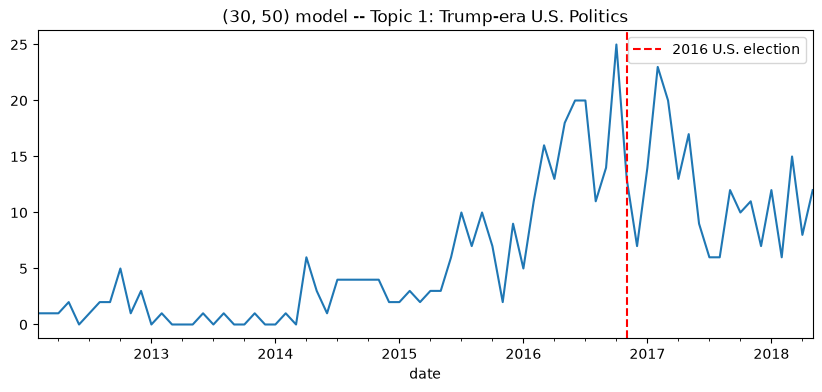

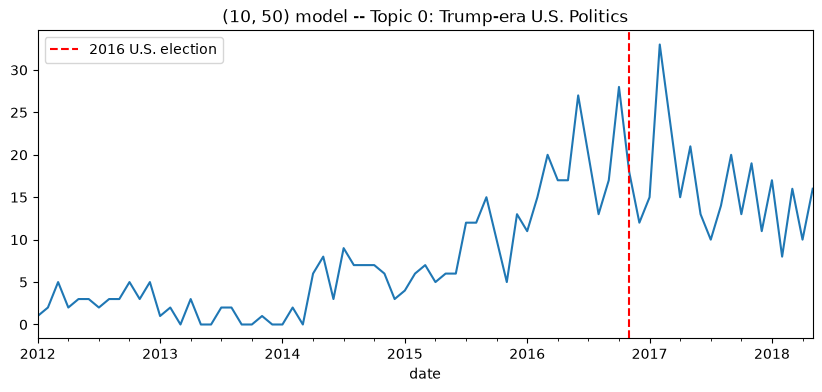

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

def topic_over_time(model, metadata, topic_id, freq="ME"):
    """Count articles assigned to a given topic per time period."""
    df_topic = metadata.copy()
    df_topic["topic"] = model.topics_
    df_topic["date"] = pd.to_datetime(df_topic["date"])

    return (
        df_topic[df_topic["topic"] == topic_id]
        .set_index("date")
        .resample(freq)
        .size()
    )

election_date = pd.Timestamp("2016-11-08")

# (30, 50) model -- topic 1, "Trump-era U.S. Politics"
counts_30 = topic_over_time(selected_models[(30, 50)], metadata, topic_id=1)
counts_30.plot(figsize=(10, 4), title="(30, 50) model -- Topic 1: Trump-era U.S. Politics")
plt.axvline(election_date, color="red", linestyle="--", label="2016 U.S. election")
plt.legend()
plt.show()

# (10, 50) model -- topic 0, its closest counterpart
counts_10 = topic_over_time(selected_models[(10, 50)], metadata, topic_id=0)
counts_10.plot(figsize=(10, 4), title="(10, 50) model -- Topic 0: Trump-era U.S. Politics")
plt.axvline(election_date, color="red", linestyle="--", label="2016 U.S. election")
plt.legend()
plt.show()

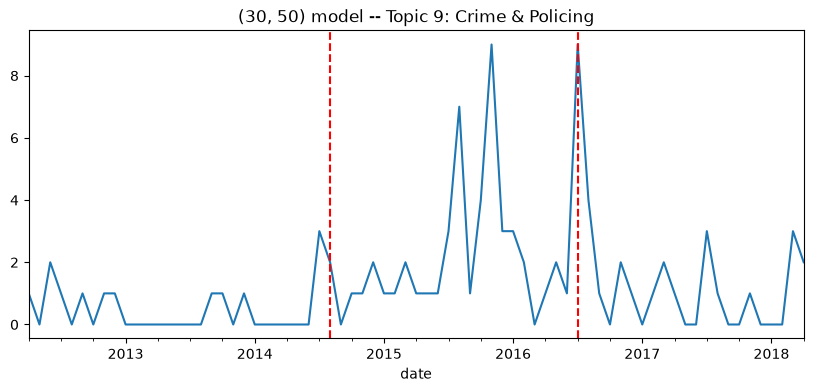

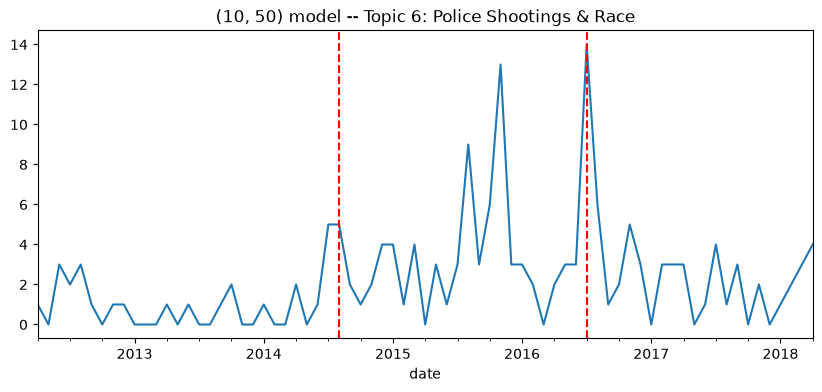

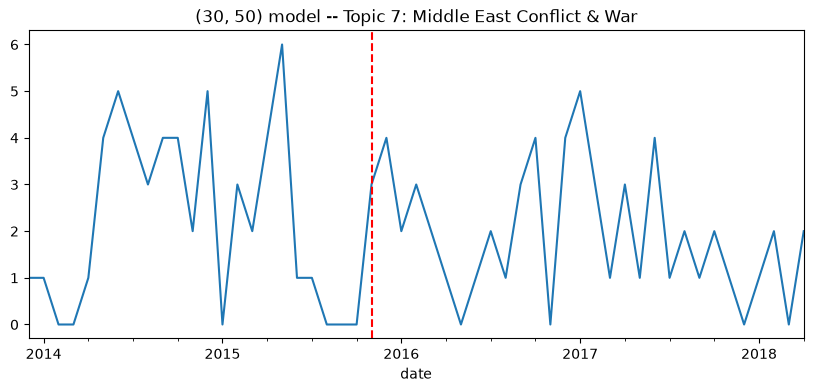

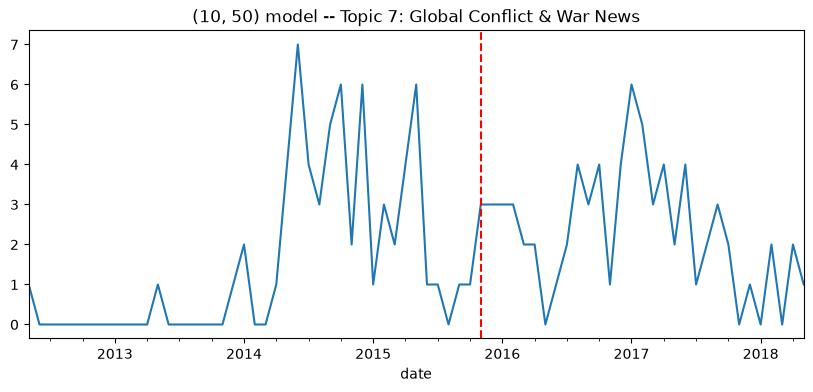

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

def topic_over_time(model, metadata, topic_id, freq="ME"):
    """Count articles assigned to a given topic per time period."""
    df_topic = metadata.copy()
    df_topic["topic"] = model.topics_
    df_topic["date"] = pd.to_datetime(df_topic["date"])

    return (
        df_topic[df_topic["topic"] == topic_id]
        .set_index("date")
        .resample(freq)
        .size()
    )

def plot_topic_with_events(model, metadata, topic_id, title, event_dates):
    counts = topic_over_time(model, metadata, topic_id=topic_id)
    counts.plot(figsize=(10, 4), title=title)
    for event_date in event_dates:
        plt.axvline(pd.Timestamp(event_date), color="red", linestyle="--")
    plt.show()

# Police shootings / racialized police violence
police_events = ["2014-08-09", "2016-07-05"]  # Ferguson; Sterling/Castile shootings
plot_topic_with_events(
    selected_models[(30, 50)], metadata, topic_id=9,
    title="(30, 50) model -- Topic 9: Crime & Policing", event_dates=police_events,
)
plot_topic_with_events(
    selected_models[(10, 50)], metadata, topic_id=6,
    title="(10, 50) model -- Topic 6: Police Shootings & Race", event_dates=police_events,
)

# Middle East conflict / ISIS
paris_attacks = ["2015-11-13"]
plot_topic_with_events(
    selected_models[(30, 50)], metadata, topic_id=7,
    title="(30, 50) model -- Topic 7: Middle East Conflict & War", event_dates=paris_attacks,
)
plot_topic_with_events(
    selected_models[(10, 50)], metadata, topic_id=7,
    title="(10, 50) model -- Topic 7: Global Conflict & War News", event_dates=paris_attacks,
)

### Reading the Remaining External Comparisons

The two topic pairs plotted above give a more mixed picture than the
election check did, which is itself worth reporting honestly rather than
quietly dropping.

**Crime & Policing.** Both models' versions of this topic (`(30, 50)`
Topic 9 and `(10, 50)` Topic 6) trace a similar shape: a modest rise
around the Ferguson protests (August 2014), and by far their largest peak
right at the Sterling/Castile shootings (July 2016) — good evidence that
both models are picking up on real coverage of police violence, not just
noise. But both series also spike, just as sharply, in mid-2015, at a date
that doesn't correspond to either event we chose to mark. That's not a
flaw to paper over — it's a reminder that our two-event comparison is
incomplete (2015 saw plenty of other, unmarked police-violence coverage,
e.g. the Baltimore unrest after Freddie Gray's death), and a nudge to
either extend the set of comparison events or treat this check as
partial evidence rather than a clean pass/fail. The `(10, 50)` model's
peaks run noticeably higher in absolute terms, but its version of the
topic also has a higher baseline throughout — consistent with it simply
covering a broader slice of crime-related content, not necessarily with
tracking the real-world events more precisely. On this comparison, neither
model clearly outperforms the other.

**Middle East Conflict & War.** Here the correspondence is weaker still.
Both models' topics (`(30, 50)` Topic 7 and `(10, 50)` Topic 7) fluctuate
between roughly 0 and 6–7 articles per month throughout 2014–2018, and the
Paris attacks (November 2015) don't stand out as a distinct peak in either
— the value right at that date is unremarkable next to several other
peaks scattered across the series. This is a useful negative result: a
single-date marker is a poor match for a topic that tracks an ongoing,
multi-year conflict (Syria, ISIS, and related coverage didn't spike and
subside around one attack; they stayed elevated for years). It doesn't
mean either model is invalid here — it means we picked a comparison point
that isn't diagnostic for this particular topic, and a steadier external
series (e.g. a monthly count of conflict-related events from a source
like ACLED) would likely be a better fit than a single date.

Taken together, these two comparisons don't discriminate between the
`(30, 50)` and `(10, 50)` models the way the election check did — they
neither confirm nor overturn that earlier result, and mainly illustrate
that external validation is only as informative as the external
comparison point chosen.

### Interpretation: What the Reading Told Us

Going through both models topic by topic, the (30, 50) model — 12 topics
— came out clearly more interpretable overall: 8 of its 12 topics were
judged fully interpretable, and the remaining 4 only "partially" (usually
because one of several example documents was a poor fit, not because the
whole topic was incoherent). The (10, 50) model — 14 topics — fared worse
in comparison: only 6 of 14 topics were fully interpretable, with 7
judged "partially" coherent. Neither model produced a topic we judged
completely uninterpretable, but the (30, 50) model's slightly coarser
topics held together better on a close read than the finer-grained
(10, 50) model's did — a reminder that more topics is not automatically
better, even when automated coherence and diversity scores looked broadly
similar between the two.

Reading the actual documents, rather than relying on top words alone,
mattered in both directions. Take the (30, 50) model's topic 4, with top
words `life, meditation, things, mindfulness, lives, good, people,
really, gps, self` — the word `gps` looks like noise, out of place next
to "meditation" and "mindfulness." But one of its example documents,
*"Peaceful Pumpkin Art (PHOTOS)"*, opens with: *"The stress and strain of
constantly being connected can sometimes take your life — and your
well-being — of course. GPS..."* Read in context, `gps` isn't noise at
all; it's part of a genuine point about digital overload and mindfulness.
Conversely, the (10, 50) model's topic 8 — top words `game, football,
players, vs, nfl, baseball, nba, dies, win, team` — has an odd word,
`dies`, that turns out to trace to *"Comedian Jerry Lewis Dead At 91"*, an
obituary that has nothing to do with sports at all. Here, reading the
document confirms the word really is noise, mixed in from an unrelated
article.

Top words can also look narrower than the documents actually justify. The
(10, 50) model's topic 7 has top words `iraq, isis, syria, afghanistan,
syrian, war, military, government, islamic, forces` — pointing squarely
at the ISIS/Syria conflict. Its example documents, though, include *"A
Deepening Political Crisis In Pakistan"* and *"U.S.: Russia Sent Tanks,
Rocket Launchers To Rebels In Ukraine"* — conflicts with no direct
connection to Syria or ISIS. The top words undersell how broad this topic
actually is; it reads more like "international conflict and war news" in
general. In the other direction, the (30, 50) model's topic 2 (`photos,
summer, travel, world, new, beach, island, trip, city, best`) is a fairly
clean travel topic, except for one outlier document, *"Mountain Lion
Tracked By Scientists Is Found Dead Near Malibu Road"* — a wildlife
conservation story with no real travel angle, despite landing in this
topic.

It's also worth comparing what we found against the expectations set out
in "Planning a Validation Strategy" above: we expected at least some
broad, recognizable news themes to emerge, and we did find clear topics
for politics, entertainment/style, and sports in both models — but
neither model produced a distinct business/economy topic, despite that
being one of our stated expectations for a general-interest news outlet.
There's a hint of where that content went: the (30, 50) model's politics
topic (topic 1) includes *"68 Public College Presidents Make More Than
President Obama"* — an article that is arguably as much about pay and
economics as it is about politics, but got absorbed into the politics
topic rather than forming a distinct business/economy theme of its own.
This doesn't necessarily mean either model is invalid, but it's exactly
the kind of gap a stated expectation is useful for catching, and worth
investigating further (Is business news underrepresented in our
5,000-article sample? Did it get folded into politics more broadly? Would
different hyperparameters surface it separately?) rather than being
quietly ignored.

### Selecting Our Final Model

Pulling together everything from this Model Selection section: quantitative
screening ranked the `(30, 50)` model first among eighteen candidates on
the balance of coherence and diversity metrics, with `(10, 50)` a close
second; internal qualitative inspection found its topics held together
better on a close read (8 of 12 fully interpretable, versus 6 of 14 for
`(10, 50)`); and the cleanest of our three external comparisons — the 2016
election check — also favored it. The other two external comparisons
didn't clearly discriminate between the two models, but didn't count
against `(30, 50)` either. Three largely independent lines of evidence
pointing the same direction is a stronger basis for a decision than any
one of them on its own, so this tutorial selects the `(30, 50)` model — 12
topics — as its final model.

That's where model *selection* ends. The next section, **Model
Validation**, does something different: rather than comparing candidates
against each other to pick a winner, it makes the positive case for why
this specific, already-chosen model should be trusted as a basis for
further analysis.

## Model Validation

Having selected the `(30, 50)` model, we now do something different from
everything above: rather than comparing it against other candidates, we
build a positive case for *why* this specific model should be trusted as a
basis for further analysis. As the "What Do We Mean by 'Validation'?"
section laid out, this is not a search for proof that the model has found
the one "true" partition of the corpus — no such partition exists for an
inductive, unsupervised method like this one. It is instead an argument,
made explicitly enough for a reader to judge for themselves, that this
particular model is fit for the purpose this tutorial set out at the
start: producing broad, interpretable, recognizable news themes from a
general-interest outlet's headlines.

### Theoretical Justification

Revisit the description of a good model from "Planning a Validation
Strategy": individually interpretable topics that include the broad,
recognizable themes we'd expect from a general-interest news outlet. The
`(30, 50)` model largely meets that bar — as the reading above found, 8 of
its 12 topics were fully interpretable and the rest only partially so,
with clear, recognizable topics for U.S. politics, entertainment/style,
sports, travel, and food, among others. It also has a genuine gap against
that same description: no distinct business/economy topic emerged, with
that content instead folded into the politics topic (see "Interpretation:
What the Reading Told Us" above). A validation argument that only reported
the successes and stayed silent about this gap would be less honest, and
less useful to a reader deciding whether to trust the model for their own
purposes, than one that names it directly: for research questions where
business or economic coverage matters, this specific model would need
further work (e.g., a smaller `min_topic_size`, or the hyperparameter
sweep re-run on a larger or more business-heavy sample) before it could be
considered valid for that purpose, even though it validates well against
the broader goal this tutorial set out with.

### Methodological Justification

The choice of BERTopic itself, and of these particular hyperparameters,
also needs a theoretical argument, not just an empirical one. As the
introduction discussed, BERTopic defines a topic as a semantic cluster of
documents in an embedding space, rather than a distribution over
co-occurring words the way LDA does. That definition suits this corpus
well: headlines and one-sentence descriptions are too short to give a
word-co-occurrence model like LDA much to work with, but they carry
plenty of semantic meaning a pretrained embedding model can pick up on.
Within BERTopic's own hyperparameters, favoring `n_neighbors=30` over `10`
means favoring more global structure in the embedding space over more
local structure when reducing dimensionality — which fits a goal of
recovering broad, general-interest news sections rather than many narrow,
hyper-specific micro-clusters. `min_topic_size=50` keeps individual topics
large enough to read and label with confidence, given a 5,000-document
sample spread thinly across dozens of potential themes; a much smaller
minimum would very likely reproduce the pattern already visible in the
quantitative screening table, where the smallest `min_topic_size` values
produced well over 100 topics — more than any reasonable amount of human
judgment could validate.

### Convergence Across Validation Angles

Finally, the strength of this validation argument rests partly on
triangulation: we didn't reach for the `(30, 50)` model with a single
method and stop there. Automated coherence and diversity metrics, a close
qualitative reading of topics and documents, and an external comparison
against a real-world event each independently pointed toward the same
model, using different kinds of evidence with different blind spots (see
"What Do We Mean by 'Validation'?" above). When independent angles agree,
that agreement is itself evidence — not because any one of them is
conclusive on its own, but because it's less likely that all of them would
happen to be wrong in the same direction. This is the argument that
separates model validation from model selection: selection asked "which
model looks best," while validation asks, and gives an explicit answer to,
"why should this model, specifically, be trusted" — theoretically,
methodologically, and across multiple, independent forms of evidence.

## Finalizing the Topic Set: Merging and Disregarding Topics

Even once a model is selected and validated, the topics as fitted aren't
necessarily the topics you'll report. Two further researcher decisions are
common at this stage, and both are a legitimate part of using a topic
model, not a way of quietly engineering a cleaner-looking result:

- **Merging.** Two topics can each be individually interpretable and still,
  substantively, be the same underlying theme split across two clusters
  (for example, a topic on campaign politics and a separate one on the
  presidency that a reader would naturally treat as one). Maier and
  colleagues [-@maier2018applying] describe using hierarchical clustering
  on topics' top-word representations to spot such mergeable pairs
  systematically, rather than relying on eyeballing alone.
- **Disregarding.** Some topics survive quantitative screening but still
  turn out, on reading, to be genuinely uninterpretable — no coherent
  theme, just noise that happened to cluster together. None of our final
  `(30, 50)` model's 12 topics fell into this category (see
  "Interpretation: What the Reading Told Us" above), but this is common
  with noisier corpora, less conservative hyperparameters, or a smaller
  `min_topic_size`.

Whatever you decide, these are the researcher's judgment calls to make —
and to report, not automatable steps (see "Reporting" below). But both
come with a specific danger: merging or dropping topics changes which
documents your subsequent analysis actually covers, and if that change
isn't close to random, it can quietly bias what you find. A disregarded
topic that disproportionately contains articles from one time period, one
section, or one underlying group changes the composition of what remains
— and any downstream claim ("topic X increased over time," "topic Y is
associated with Z") silently inherits that bias.

In [17]:
def dropped_document_bias(model, metadata, dropped_topic_ids, group_col="category", top_n=8):
    """
    Compare the composition of documents that would be removed (because
    their topic is being disregarded, or folded into a merge) against the
    full corpus, on some grouping column (e.g. `category`). A `ratio` far
    from 1 for some group is a warning sign that the removal isn't a
    random slice of the data.
    """
    df_check = metadata.copy()
    df_check["topic"] = model.topics_
    dropped = df_check[df_check["topic"].isin(dropped_topic_ids)]

    share_dropped = len(dropped) / len(df_check)
    full_dist = df_check[group_col].value_counts(normalize=True)
    dropped_dist = dropped[group_col].value_counts(normalize=True)

    comparison = pd.DataFrame({
        "share_in_full_corpus": full_dist,
        "share_among_dropped": dropped_dist,
    }).fillna(0)
    comparison["ratio"] = (
        comparison["share_among_dropped"] / comparison["share_in_full_corpus"]
    ).replace([float("inf")], float("nan"))

    print(f"Dropping topics {dropped_topic_ids} removes "
          f"{len(dropped)} of {len(df_check)} documents ({share_dropped:.1%}).")
    return comparison.sort_values("ratio", ascending=False).head(top_n)


# Illustrative only: our selected (30, 50) model had no topics we judged
# uninterpretable, so there's nothing to disregard here. If, say, topics 5
# and 11 had come out as unreadable noise, this is how you'd check whether
# dropping them would disproportionately remove one kind of content:
# dropped_document_bias(selected_models[(30, 50)], metadata, dropped_topic_ids=[5, 11])

If a check like this turns up a `ratio` well above or below 1 for some
group, that's a signal the removal isn't random — worth investigating
(and reporting) rather than quietly proceeding. This applies just as much
to merging as to disregarding: after merging two topics, run a similar
check comparing the merged topic's composition against what you'd expect,
to make sure the merge hasn't quietly combined substantively different
kinds of documents into one, harder-to-interpret whole. The `outlier_share`
we tracked during quantitative screening above is a version of exactly
this same concern, applied to the outlier topic rather than a merged or
disregarded one — the underlying question is always "who's missing from
what I'm about to analyze, and why?"

## Reporting

Everything above is only as useful to a reader as what actually gets
reported. Bernhard-Harrer et al. [-@bernhardharrer2026beyond] find that
alongside the "validation gap" (too little validation) and "standardization
gap" (no converged-on methods), the field also has a "reporting gap": even
when researchers do validate their topic models, publications often don't
say enough about how, making it hard for a reader to judge whether a
study's validation argument actually holds up. Since this tutorial has
argued throughout that there is no universal recipe to point to instead —
validity has to be argued for, case by case — transparent reporting is
what lets a reader evaluate that argument at all, rather than take it on
faith.

At minimum, a write-up using this tutorial's approach should report:

1. **Preprocessing decisions** and why they were (or weren't) applied —
   for BERTopic, this is a shorter list than for classical methods, but
   it should still be stated explicitly (see "Preprocessing" above).
2. **The hyperparameter search space** actually swept (which parameters,
   which values, and why those bounds), and the final values chosen.
3. **Screening results** for all candidate models, not just the winner —
   the full ranked table, not a single cherry-picked score, so a reader
   can see how close the field was and judge the selection for themselves.
4. **Which selection methods were used and why**, tied back to the
   description of a good model from the planning stage — not just which
   model was picked, but on what combination of evidence.
5. **Validation methods and results**, kept visibly separate from
   selection, including any gaps or limitations found (like the missing
   business/economy topic here) rather than only the successes.
6. **Any topics merged or disregarded**, the criteria used to decide, the
   share of documents affected, and the outcome of a bias check like the
   one above — or an explicit statement that no such check was run, if
   that's the case.
7. **The outlier share** of the final model, and whether any outlier
   reduction was applied.
8. **Limitations**, stated plainly — what this validation strategy does
   *not* establish (e.g., we validated for broad thematic interpretability
   for a general audience, not for any specific downstream research
   question), and what a reader with a different purpose in mind should
   check for themselves before reusing this model.

None of this needs to be exhaustive prose — a table, an appendix, or
supplementary code (like this notebook itself) can carry most of it. What
matters is that a reader can reconstruct *why* this specific model was
selected and judged valid, not just *that* it was.

## Conclusion

You now have a hands-on template for validating a BERTopic model:
distinguishing model *selection* (screening candidates down to a
shortlist, then narrowing that shortlist with internal and external
qualitative inspection) from model *validation* (building an explicit,
theoretically and methodologically grounded case for why the chosen model
should be trusted) rather than conflating the two; combining quantitative
screening, internal qualitative inspection, and external qualitative
inspection into a single strategy; deciding whether to merge or disregard
topics while checking that decision for hidden bias; and reporting the
whole process transparently enough for a reader to judge it themselves.

None of the specific choices made along the way — BERTopic over LDA,
these two swept hyperparameters, this particular shortlist, this external
comparison — are meant to be copied wholesale into your own project. What
should transfer is the process: state what a good model would look like
before you start, keep selection and validation conceptually separate,
draw on more than one kind of evidence, and report enough that someone
else could follow your reasoning even where they might have made a
different call. That is what it means to validate an inductive,
unsupervised method like topic modeling in the absence of a gold standard
— not applying a fixed checklist, but making, and defending, a series of
justified choices.

## References